In [3]:
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration
import matplotlib.pyplot as plt
import cv2
import numpy as np
import webcolors
from gigachat import GigaChat
from gigachat import GigaChat
from gigachat.models import Chat, Messages, MessagesRole
import json
import os
from dotenv import load_dotenv

load_dotenv()

# Captioning изображения BLIP

print("[INFO] Загружаем BLIP-2...")
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model_blip = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

def generate_caption(image_path: str):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")
    out = model_blip.generate(**inputs)
    caption = processor.decode(out[0], skip_special_tokens=True)
    return caption

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


[INFO] Загружаем BLIP-2...


C:\Users\iva05\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\iva05\.cache\huggingface\hub\models--Salesforce--blip-image-captioning-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Fallin

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


In [4]:
giga = GigaChat(
    credentials=os.getenv("AUTH_KEY"),
    verify_ssl_certs=False,
)

SYSTEM_PROMPT = """You are a professional fashion expert.
You will receive short clothing descriptions.
Your task: convert each description into a detailed JSON with keys:
{
  "gender": "...",
  "category": "...",
  "style": "...",
  "color": "...",
  "season": "...",
  "material": "...",
  "description": "..."
}
Output only valid JSON, without explanations."""

def ask_gigachat(caption: str) -> dict:
    response = giga.chat(
        Chat(
            messages=[
                Messages(role=MessagesRole.SYSTEM, content=SYSTEM_PROMPT),
                Messages(role=MessagesRole.USER, content=caption),
            ]
        )
    )

    content = response.choices[0].message.content.strip()
    
    try:
        data = json.loads(content)
    except json.JSONDecodeError:
        print("[WARN] GigaChat вернул невалидный JSON:")
        print(content)
        data = {"raw_response": content}

    return data

In [5]:
def find_color(path):
    # --- Загрузка изображения ---
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # --- Разворачиваем изображение в список пикселей ---
    pixels = image.reshape(-1, 3)

    # --- Определяем фон (белый) ---
    def is_white(pixel, threshold=200):
        return all(channel > threshold for channel in pixel)

    # --- Отбрасываем пиксели фона ---
    filtered_pixels = np.array([pixel for pixel in pixels if not is_white(pixel, threshold=200)])

    # Если нет оставшихся пикселей — fallback
    if len(filtered_pixels) == 0:
        filtered_pixels = pixels

    # --- Вычисляем средний цвет ---
    mean_color = tuple(np.mean(filtered_pixels, axis=0).astype(int))

    # --- Функция округления цвета до палитры CSS3 ---
    def closest_color_name(requested_color):
        min_distance = float("inf")
        closest_name = None
        for name in webcolors.names("css3"):
            r_c, g_c, b_c = webcolors.name_to_rgb(name)
            distance = np.sqrt((r_c - requested_color[0])**2 +
                              (g_c - requested_color[1])**2 +
                              (b_c - requested_color[2])**2)
            if distance < min_distance:
                min_distance = distance
                closest_name = name

        return closest_name

    color_name = closest_color_name(mean_color)
    return color_name


def fashion_metadata_pipeline(image_path: str):
    print("[INFO] Генерация описания...")
    caption = generate_caption(image_path)
    color = find_color(image_path)

    description = color + " " +  caption

    print(f"[INFO] Caption: {description}")
    print("📋 Product Information:")
    data = ask_gigachat(description)
    for key, value in data.items():
        print(f"  {key}: {value}")


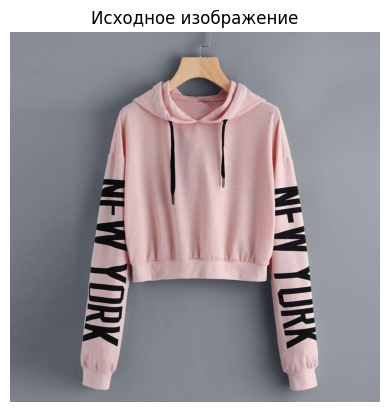

[INFO] Генерация описания...
[INFO] Caption: gray a pink cropped cropped cropped cropped cropped cropped cropped cropped cropped
📋 Product Information:
  gender: unisex
  category: cropped tops
  style: cropped
  color: gray and pink
  season: neutral
  material: unknown
  description: a gray and pink cropped top


In [6]:
IMG_PATH = 'pics/blouse.jpeg'

bgr = cv2.imread(IMG_PATH)
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

plt.imshow(rgb);
plt.title('Исходное изображение');
plt.axis('off');
plt.show()


fashion_metadata_pipeline(IMG_PATH)